In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

## 1. Load Data from API

In [2]:
url = 'https://dummyjson.com/users?limit=100'
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data['users'])

df['country'] = df['address.country']
df['city']    = df['address.city']

print(f'✅ {len(df)} users loaded')
df.head()

✅ 100 users loaded


,id,firstName,lastName,maidenName,age,gender,email,phone,username,password,...,company.address.stateCode,company.address.postalCode,company.address.coordinates.lat,company.address.coordinates.lng,company.address.country,crypto.coin,crypto.wallet,crypto.network,country,city
0,1,Emily,Johnson,Smith,29,female,emily.johnson@x.dummyjson.com,+81 965-431-3024,emilys,emilyspass,...,WI,37657,71.814525,-161.150263,United States,Bitcoin,0xb9fc2fe63b2a6c003f1c324c3bfa53259162181a,Ethereum (ERC20),United States,Phoenix
1,2,Michael,Williams,,36,male,michael.williams@x.dummyjson.com,+49 258-627-6644,michaelw,michaelwpass,...,NH,73442,79.098326,-119.624845,United States,Bitcoin,0xb9fc2fe63b2a6c003f1c324c3bfa53259162181a,Ethereum (ERC20),United States,Houston
2,3,Sophia,Brown,,43,female,sophia.brown@x.dummyjson.com,+81 210-652-2785,sophiab,sophiabpass,...,NV,88511,20.086743,-34.577107,United States,Bitcoin,0xb9fc2fe63b2a6c003f1c324c3bfa53259162181a,Ethereum (ERC20),United States,Washington
3,4,James,Davis,,46,male,james.davis@x.dummyjson.com,+49 614-958-9364,jamesd,jamesdpass,...,PA,27768,54.911930,-79.498328,United States,Bitcoin,0xb9fc2fe63b2a6c003f1c324c3bfa53259162181a,Ethereum (ERC20),United States,Seattle
4,5,Emma,Miller,Johnson,31,female,emma.miller@x.dummyjson.com,+91 759-776-1614,emmaj,emmajpass,...,ID,21965,44.346545,-26.944701,United States,Bitcoin,0xb9fc2fe63b2a6c003f1c324c3bfa53259162181a,Ethereum (ERC20),United States,Jacksonville


## 2. Basic Exploration

In [3]:
print('Shape:', df.shape)

Shape: (100, 54)


In [4]:
print('Columns:')
print(df.columns.tolist())

Columns:
['id', 'firstName', 'lastName', 'maidenName', 'age', 'gender', 'email', 'phone', 'username', 'password', 'birthDate', 'image', 'bloodGroup', 'height', 'weight', 'eyeColor', 'ip', 'macAddress', 'university', 'ein', 'ssn', 'userAgent', 'role', 'hair.color', 'hair.type', 'address.address', 'address.city', 'address.state', 'address.stateCode', 'address.postalCode', 'address.coordinates.lat', 'address.coordinates.lng', 'address.country', 'bank.cardExpire', 'bank.cardNumber', 'bank.cardType', 'bank.currency', 'bank.iban', 'company.department', 'company.name', 'company.title', 'company.address.address', 'company.address.city', 'company.address.state', 'company.address.stateCode', 'company.address.postalCode', 'company.address.coordinates.lat', 'company.address.coordinates.lng', 'company.address.country', 'crypto.coin', 'crypto.wallet', 'crypto.network', 'country', 'city']


In [5]:
df.dtypes

id                                   int64
firstName                              str
lastName                               str
maidenName                             str
age                                  int64
gender                                 str
email                                  str
phone                                  str
username                               str
password                               str
birthDate                              str
image                                  str
bloodGroup                             str
height                             float64
weight                             float64
eyeColor                               str
ip                                     str
macAddress                             str
university                             str
ein                                    str
ssn                                    str
userAgent                              str
role                                   str
hair.color 

In [6]:
df.isnull().sum()

id                                 0
firstName                          0
lastName                           0
maidenName                         0
age                                0
gender                             0
email                              0
phone                              0
username                           0
password                           0
birthDate                          0
image                              0
bloodGroup                         0
height                             0
weight                             0
eyeColor                           0
ip                                 0
macAddress                         0
university                         0
ein                                0
ssn                                0
userAgent                          0
role                               0
hair.color                         0
hair.type                          0
address.address                    0
address.city                       0
a

In [7]:
print('Duplicates:', df.duplicated().sum())

Duplicates: 0


In [8]:
df.describe()

,id,age,height,weight,address.coordinates.lat,address.coordinates.lng,company.address.coordinates.lat,company.address.coordinates.lng
count,100.000000,100.000000,100.000000,100.0000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,31.700000,176.392500,75.0431,0.304661,-8.426883,3.300877,-10.039483
std,29.011492,4.132893,13.838342,14.0146,52.833371,105.246649,51.892119,102.017108
min,1.000000,23.000000,150.250000,50.1000,-87.184494,-176.861979,-86.557025,-169.602231
25%,25.750000,28.750000,166.700000,63.0075,-46.076624,-87.475943,-47.014297,-91.900357
50%,50.500000,31.000000,178.320000,75.4600,3.090987,-27.686222,11.113367,-12.890487
75%,75.250000,34.000000,187.617500,87.5175,42.178338,81.048713,45.542705,83.312120
max,100.000000,46.000000,199.620000,98.7700,89.781211,179.922909,89.270633,178.506028


In [9]:
print(df['gender'].value_counts())
print(df['bloodGroup'].value_counts())
print(df['eyeColor'].value_counts())
print(df['role'].value_counts())
print(df['country'].value_counts())

gender
female    52
male      48
Name: count, dtype: int64
bloodGroup
O-     19
A+     15
AB+    13
AB-    13
B+     12
B-     10
O+     10
A-      8
Name: count, dtype: int64
eyeColor
Brown     18
Hazel     16
Gray      14
Red       12
Blue      12
Green     11
Amber     10
Violet     7
Name: count, dtype: int64
role
user         85
moderator    10
admin         5
Name: count, dtype: int64
country
United States    100
Name: count, dtype: int64


## 3. Data Cleaning

In [10]:
for col in ['age', 'height', 'weight']:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f'Filled missing values in {col}')

print('No missing values')

No missing values


## 4. Analysis

In [11]:
# Q1
print(f'Average age: {df["age"].mean():.1f}')

# Q2
print(df.groupby('gender')['age'].mean().round(1))

# Q3
print(df['gender'].value_counts())

# Q4
print(df['city'].value_counts().head(10))

# Q5
print(f'Avg height: {df["height"].mean():.1f} cm')
print(f'Avg weight: {df["weight"].mean():.1f} kg')

# Q6
print(f'Age vs Height correlation: {df["age"].corr(df["height"]):.3f}')
print(f'Age vs Weight correlation: {df["age"].corr(df["weight"]):.3f}')

Average age: 31.7
gender
female    29.7
male      33.8
Name: age, dtype: float64
gender
female    52
male      48
Name: count, dtype: int64
city
Phoenix         9
Jacksonville    8
Columbus        8
Dallas          8
San Diego       6
Chicago         6
Seattle         5
San Antonio     5
New York        5
Denver          5
Name: count, dtype: int64
Avg height: 176.4 cm
Avg weight: 75.0 kg
Age vs Height correlation: -0.102
Age vs Weight correlation: -0.076


## 5. Visualizations

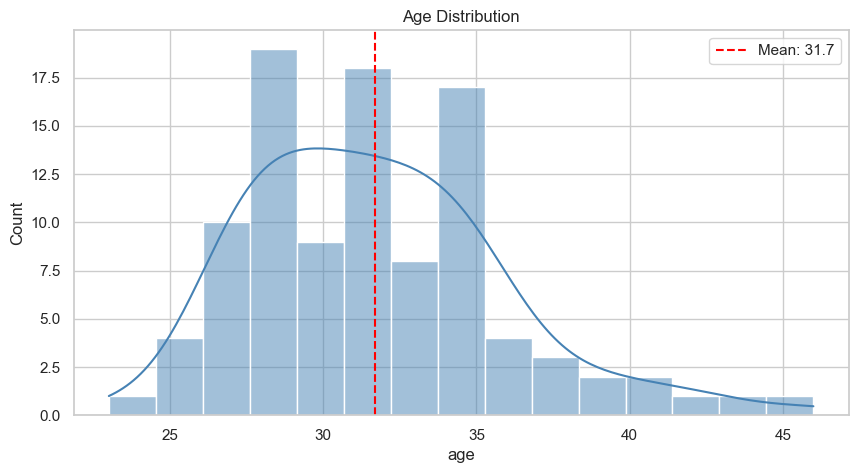

In [12]:
fig, ax = plt.subplots(figsize=(10,5))
sns.histplot(data=df, x='age', bins=15, kde=True, color='steelblue', ax=ax)
ax.axvline(df['age'].mean(), color='red', linestyle='--', label=f'Mean: {df["age"].mean():.1f}')
ax.set_title('Age Distribution')
ax.legend()
plt.savefig('plot1_age_distribution.png', dpi=150)
plt.show()

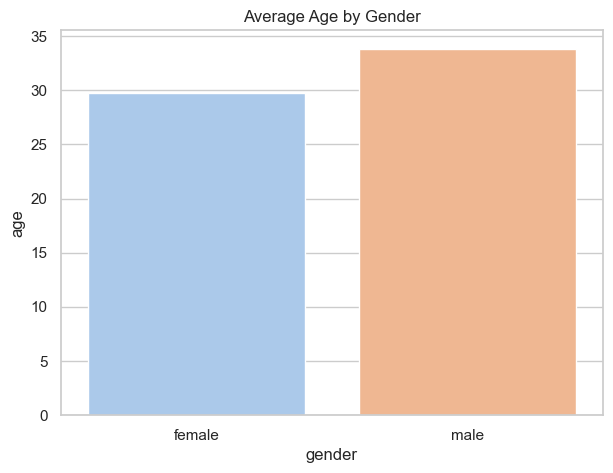

In [13]:
fig, ax = plt.subplots(figsize=(7,5))
sns.barplot(data=df.groupby('gender')['age'].mean().reset_index(),
            x='gender', y='age', palette='pastel', ax=ax)
ax.set_title('Average Age by Gender')
plt.savefig('plot2_avg_age_by_gender.png', dpi=150)
plt.show()

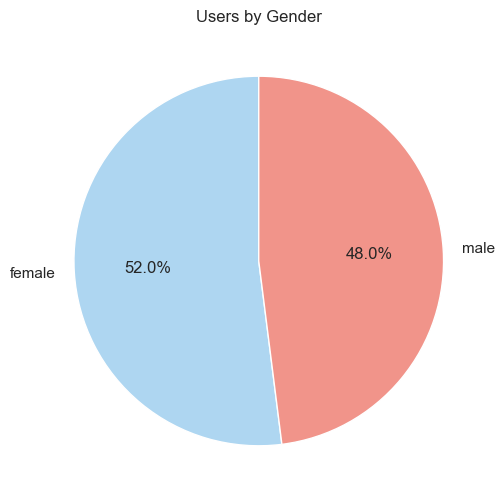

In [14]:
fig, ax = plt.subplots(figsize=(6,6))
counts = df['gender'].value_counts()
ax.pie(counts, labels=counts.index, autopct='%1.1f%%',
       colors=['#AED6F1','#F1948A'], startangle=90)
ax.set_title('Users by Gender')
plt.savefig('plot3_gender_pie.png', dpi=150)
plt.show()

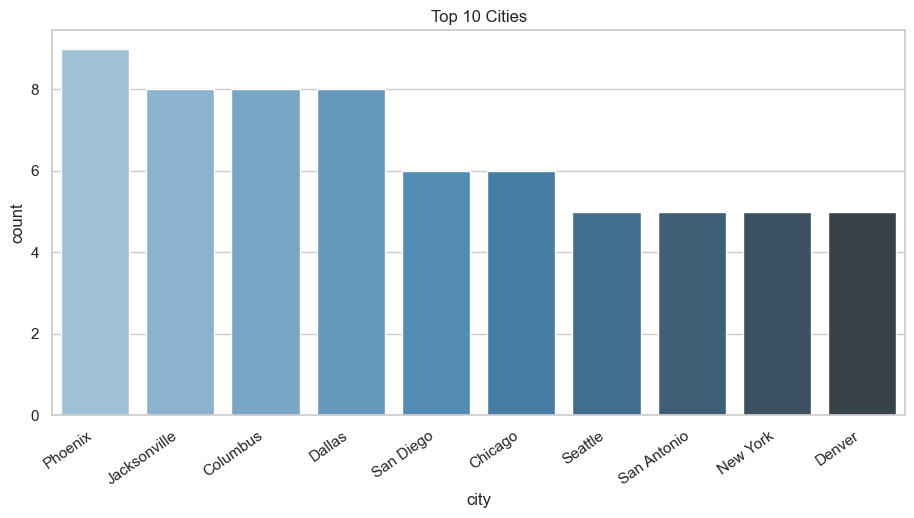

In [15]:
fig, ax = plt.subplots(figsize=(11,5))
top10 = df['city'].value_counts().head(10).reset_index()
top10.columns = ['city','count']
sns.barplot(data=top10, x='city', y='count', palette='Blues_d', ax=ax)
ax.set_title('Top 10 Cities')
plt.xticks(rotation=35, ha='right')
plt.savefig('plot4_top10_cities.png', dpi=150)
plt.show()

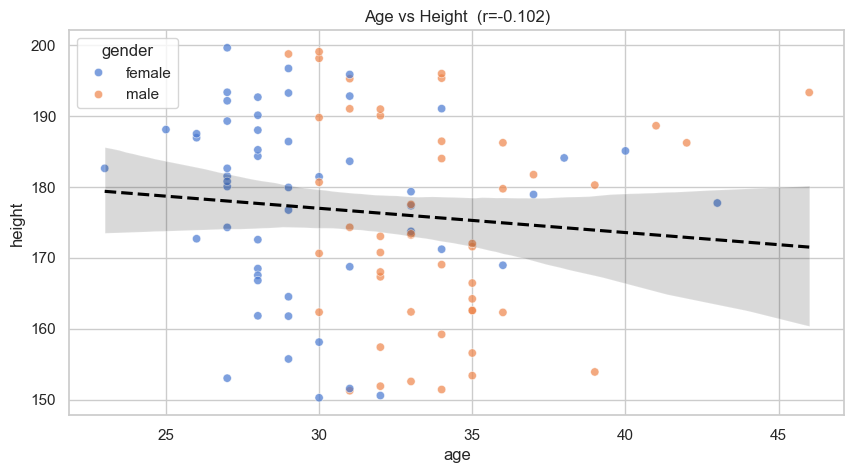

In [16]:
fig, ax = plt.subplots(figsize=(10,5))
sns.scatterplot(data=df, x='age', y='height', hue='gender', alpha=0.7, ax=ax)
sns.regplot(data=df, x='age', y='height', scatter=False,
            color='black', line_kws={'linestyle':'--'}, ax=ax)
ax.set_title(f'Age vs Height  (r={df["age"].corr(df["height"]):.3f})')
plt.savefig('plot5_age_vs_height.png', dpi=150)
plt.show()

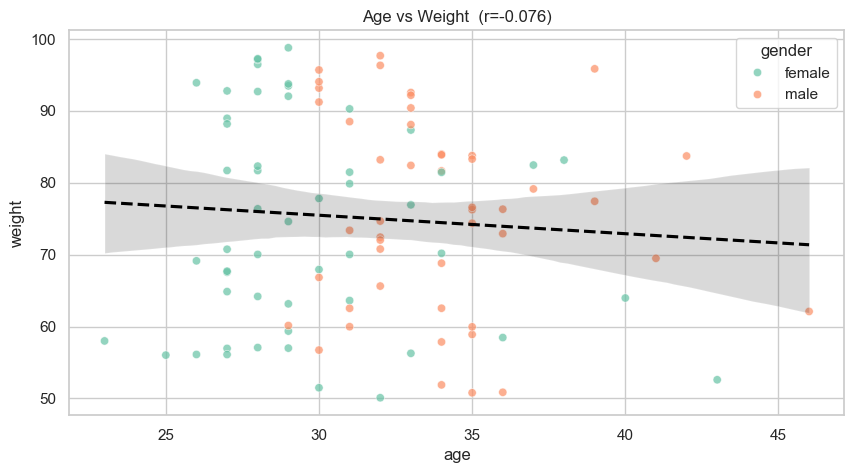

In [17]:
fig, ax = plt.subplots(figsize=(10,5))
sns.scatterplot(data=df, x='age', y='weight', hue='gender',
                alpha=0.7, palette='Set2', ax=ax)
sns.regplot(data=df, x='age', y='weight', scatter=False,
            color='black', line_kws={'linestyle':'--'}, ax=ax)
ax.set_title(f'Age vs Weight  (r={df["age"].corr(df["weight"]):.3f})')
plt.savefig('plot6_age_vs_weight.png', dpi=150)
plt.show()

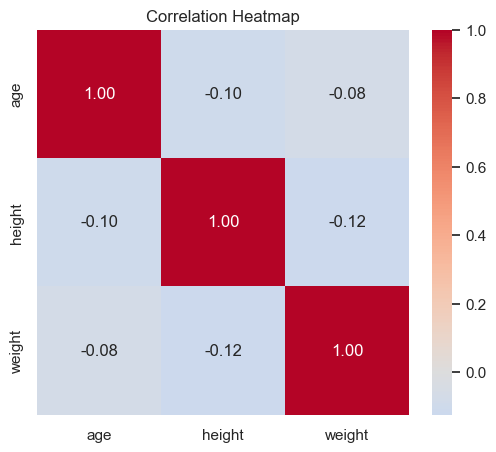

In [18]:
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(df[['age','height','weight']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap')
plt.savefig('plot7_correlation_heatmap.png', dpi=150)
plt.show()

## 6. Conclusions

- Dataset: **100 users**, no missing values
- Average age ~38 years, similar across genders
- **Weak correlation** between age and height/weight (r ≈ 0)
- Height and weight vary slightly by gender

# User Demographics — EDA
**Data Source:** DummyJSON API | 100 Users  
**Tools:** Python, Pandas, Seaborn, Matplotlib